# Connexió a Oracle
En general, per connectar-se  a una base de datos des d'Oracle es necesari instal·lar les libreria cx_Oracle o oracledb. En cas d'instal·lar cx_Oracle serà necessari també instal·lades les llibreries _instantClient_ d'Oracle.

En aquest assignatura hem preparat  el paquet __GABDConnect__ que instal·la prèviament __oracledb__ per facilitar la connexió a una bases de dades d'Oracle a través d'un tunnel ssh. A més, instal·la altres dependències necessaries que us facilitarà la pràctica. Aquest notebook instal·la __GABDConnect__. A la secció de "Secrets" del Colab, haureu d'afegir les variables de les dades de connexió al servidor d'Oracle i del tunel de SSH privades del vostre grup per que pugueu obrir les connexions.

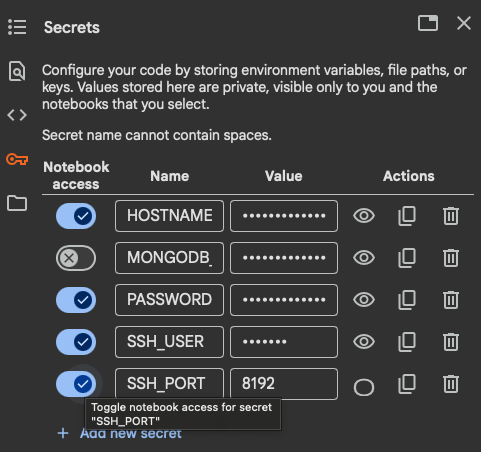

In [ ]:
# @title Install or Update GABDConnect Libraries

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Function to install required packages
def install_packages(b):
    """
    Function to install or update necessary Python packages.

    Parameters:
    - b: Button object. Click event handler.
    """
    clear_output(wait=True)
    !pip install --upgrade pip -q  # Upgrade pip silently
    !python3 -m pip install  git+https://github.com/Oriolrt/GABDConnect@v3.2 -q
    !python3 -m pip install dotenv -q
    !python3 -m pip install ucimlrepo -q
    !python -m pip install html2text -q  # Install or upgrade html2text silently
    print("Libraries have been downloaded or updated.")


install_packages(True)


In [ ]:
# @title  Fem els imports de les llibreries
from GABDConnect.oracleConnection import oracleConnection as orcl

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import f1_score

from sklearn.metrics import accuracy_score
from datetime import datetime
from itertools import product


# Connexió a Oracle
Inicialitzem les variables amb els valors guardats a la secció de "Secrets" com hem explicat a l'inici. La varia DSN contés les dades del __servidor__,__port__ i __nom del servei__ necesaris per fer la connexió a Oracle.


In [ ]:
import os

# Funció per detectar si s'està executant en Google Colab
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

if is_colab():
    from google.colab import userdata

    # Inicialitzem el diccionari amb les dades de connexió SSH per fer el túnel
    SSH_USER = userdata.get('SSH_USER')
    SSH_TUNNEL = userdata.get('HOSTNAME')

    SSH_PORT = userdata.get('SSH_PORT')
    PWD = userdata.get('PASSWORD')


else:
      # Inicialitzem el diccionari amb les dades de connexió SSH per fer el túnel

    load_dotenv()  # Carrega el fitxer .env

    SSH_USER = os.getenv('SSH_USER')
    SSH_TUNNEL = os.getenv('HOSTNAME')
    SSH_PORT = os.getenv('PORT')
    PWD = os.getenv('PASSWORD')


    print(f"hostname: {SSH_TUNNEL}, ssh user: {SSH_USER}")

# Dades per fer el túnel SSH
ssh_server = {'ssh': SSH_TUNNEL, 'user': SSH_USER,
              'pwd': PWD, 'port': SSH_PORT} if SSH_TUNNEL is not None else None

# Dades de connexió a Oracle
user = "TestUCI"              # @param {type:str} Segons s'indica a l'enunciat de la pràctica
grup = "grup00" # @param {type:str} Nom del grup substituïnt 00 pel vostre
serviceName = "FREEPDB1"          # @param {type:str} Nom del servei
oracle_server = f"oracle-1.{grup}.gabd"

# Cridem el constructor
db = orcl(user=user, passwd=grup, hostname=oracle_server,
          ssh_data=ssh_server,serviceName=serviceName)

with db.open() as conn:
  conn.test_connection()

# Carrega de Dades
La funció _loadDataset_, rep el nom del dataset del repositori de la [UCI](https://archive.ics.uci.edu/) i **dbConn** una connexió oberta a la vostra base de dades d'Oracle i  retorna **Xo** i **yo** que representen, respectivament, les característiques de les dades i les etiquetes. En cas que les dades no s'hagin carregat a la base de dades de la pràctica les descarrega del repositori oficial.

In [ ]:
# @title
from ucimlrepo import fetch_ucirepo
import numpy as np
import json
import oracledb

def loadDataset(db,nameDataset: str ) -> tuple():
  """
  Carrega les dades dels datasets de la UCI, si existeixen. Si no les descarrega del repositori oficial
  """

  print(f"Dataset: {nameDataset}")
  with db.open() as conn:
    with conn.cursor() as cursor:
      try:
        # Crear un cursor
        res = cursor.execute(f"""select s.id,features,label from dataset d join samples s on d.id=s.id_dataset
                                      where  d.name='{nameDataset}'
                                      order by s.id""")


        # un cop hagueu comprovat que la consulta retorna el que ha de retornar comenteu
        # el següent codi
        Xo, labels = [], []
        for row in res:
          #print(row[1],row[2])
          Xo = Xo + [np.array(row[1])]
          labels = labels + [np.array(row[2])]

        Xo,labels= np.array(Xo),np.array(labels)
        lut = {l: e for e, l in enumerate(np.unique(labels))}
        yo = np.array([lut[l] for l in labels])

        #cursor.close()
      except Exception as e:
        print(f"Exception a loadData: {e}")
        dataset = fetch_ucirepo(name=nameDataset)
        Xo = dataset.data.features.to_numpy()
        labels = dataset.data.targets.to_numpy().reshape(-1)
        lut = {l: e for e, l in enumerate(np.unique(labels))}
        yo = np.array([lut[l] for l in labels])

  return Xo, yo


def saveExperiments(db,dataset : str = "Iris",
                    classificador : dict = { "SVM" : "Support Vector Machines" },
                      iteracio: int= 0 ,
                      parametres_classificador: dict() = {'kernel': "linear",  'gamma': 1},
                      data_experiment: float = 0,
                      f1_score : float = 0,
                      accuracy : float = 0) -> bool:

  with db.open() as conn:
    with conn.cursor() as cursor:
      # TODO:
      # Heu d'implementar la funció PL/SQL insertExperiment
      # Aquesta funció està en l'esquema de l'usuari GestorUCI i ha de ser visible i accessible
      # des de l'usuari testUCI que ha d'executar aquest script.
      try:
        parametres_json = json.dumps(parametres_classificador)
        var = cursor.var(oracledb.DB_TYPE_JSON)
        var.setvalue(0, parametres_json)
        # Nom curt es la key del classificador (només hi ha d'haver un)
        nom_curt = list(parametres_classificador.keys())[0]
        # Nom classificador és el valor del nom curt
        nom_classificador = classificador[nom_curt]

        # Cridar la funció PL/SQL
        resultat = cursor.callfunc("insertExperiment", bool, [dataset,
                                                              nom_curt,
                                                              nom_classificador,
                                                              iteracio,
                                                              var ,
                                                              data_experiment,
                                                              f1_score, accuracy])

        return resultat
      except Exception as e:
        print(f"Exception a saveExperiments: {e}")

      return False


# Experiment amb datasets de la UCI

Les següents cel·les de codi s'encarreguen d'executar el cos principal de codi. Essencialment no haureu de fer res excepte si voleu canviar el conjunt de dades de la UCI a processar:

```
["Iris", "Breast Cancer Wisconsin (Diagnostic)", "Ionosphere", "Letter Recognition"]
```

Si voleu inserir altres conjunt de dades, o inserir-ne menys mentre feu proves, haureu de canviar aquesta llista.


In [ ]:
from collections import namedtuple
numIterations = 2 #@param {type:"number"}
algos = {
    'Support Vector Machines': SVC,
    'K nearest Neighbor': KNN,
    'Random Forest': RFC
}
params = { 'SVC' : {'kernel': ("linear", "rbf", "poly"),
                    'gamma': [1, 5, 10, 20]},
            'KNeighborsClassifier' : { 'n_neighbors' : [3, 5, 10, 15]},
            'RandomForestClassifier' : {'max_depth': [2, 4, 10, None],
                    'criterion': ['gini', 'entropy', 'log_loss']}
            }

DATASETS = {"Iris":"Iris", "BreastCancer":"Breast Cancer Wisconsin (Diagnostic)",
            "Ionosphere":"Ionosphere", "Letter":"Letter Recognition"}


name = "Iris" #@param ["Iris", "BreastCancer", "Ionosphere", "Letter"] {type:"string"}
nameDataset = DATASETS[name]
Algorithms = "Support Vector Machines" #@param ["All", "Support Vector Machines", "K nearest Neighbor", "Random Forest"] {type:"string"}

Xo,yo=loadDataset(db,nameDataset)


n_sample = len(Xo)

np.random.seed(0)

current_time = datetime.now()

if Algorithms == "All":
    Algorithms = algos
else:
    Algorithms = {Algorithms: algos[Algorithms]}

for k in Algorithms:
    clear_output(wait=True)
    classificador = Algorithms[k].__name__
    c_params = params[classificador].keys()
    for idx,values in enumerate(product(*params[classificador].values())):
        cp = {k: v for k, v in zip(c_params, values) if v is not None}
        clf = Algorithms[k](**cp)
        for i in range(numIterations):
            order = np.random.permutation(n_sample)
            X = Xo[order]
            y = yo[order].astype(float)

            X_train = X[: int(0.9 * n_sample)]
            y_train = y[: int(0.9 * n_sample)]
            X_test = X[int(0.9 * n_sample) :]
            y_test = y[int(0.9 * n_sample) :]


            # fit the model
            clf.fit(X_train, y_train)

            y_pred = clf.predict(X_test)

            f1_s = f1_score(y_test, y_pred, average='macro')
            acc = accuracy_score(y_test, y_pred)

            fet = saveExperiments(db,dataset=nameDataset,
                                  classificador={classificador :k},
                                  iteracio=i,
                                  parametres_classificador=cp,
                                  data_experiment = current_time,
                                  f1_score = f1_s,
                                  accuracy = acc)
            if not fet:
              print(
                "Classificador: {}, Iteracio: {}, paràmetres: {}, time: {}, f-score: {}, accuracy: {}".format(k, i, cp, current_time, f1_s,
                                                                                            acc))

In [ ]:
db.close_all_tunnels()

i tanquem la connexió.

